In [488]:
import tensorflow as tf
import h5py as h5
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import pickle
import time
from datetime import datetime
import re

from tensorflow_examples.models.pix2pix import pix2pix
from IPython.display import clear_output

In [489]:
BATCH_SIZE = 32
UNLABELLED_BATCH_SIZE = 32
SHUFFLE_SIZE = 512
IMG_SIZE = (128, 128)   # (H, W)

NUM_LABELLED_VOLS = 5
NUM_VAL_VOLS = 32
MAX_VAL_NUM = 256

LAMBDA = 0.01
BLIND_PROB = 0.5

In [490]:
with open('nonempty-paths-vols.pkl', 'rb') as file:
    vols = pickle.load(file)
    
vols.sort()

rng = random.Random(1337)

rng.shuffle(vols)
val_vols = vols[-NUM_VAL_VOLS:]
train_vols = vols[:-NUM_VAL_VOLS]
labelled_vols = train_vols[-NUM_LABELLED_VOLS:]
unlabelled_vols = train_vols[:-NUM_LABELLED_VOLS]

val_paths = [x for vol in val_vols for x in vol]
labelled_paths = [x for vol in labelled_vols for x in vol]
unlabelled_paths = [x for vol in unlabelled_vols for x in vol]

rng.shuffle(val_paths)
val_paths = val_paths[:MAX_VAL_NUM]
rng.shuffle(labelled_paths)
rng.shuffle(unlabelled_paths)

print(f"Training set: {len(labelled_paths)} labelled, {len(unlabelled_paths)} unlabelled\nValidation set: {len(val_paths)}")

Training set: 238 labelled, 15825 unlabelled
Validation set: 256


In [491]:
# THANK YOU CHATGPT FOR WRITING THIS 🙏🙏🙏🙏
# I'M GLAD THE AI UNDERSTANDS APPLE METAL GPU
# PLEASE DON'T TAKE MY JOB THO
def get_dataset(paths, img_size=IMG_SIZE, shuffle_buf=None):
    """H5 → (image, mask) with TF ops; minimal py bridge, stable on Apple Metal.
    If specified (not None), `peekaboo` will randomly hide all channels except one with probability `peekaboo`"""

    # --- tiny py bridge: read raw arrays from .h5 ---
    def _read_h5(path):
        path = path.numpy().decode("utf-8")
        with h5.File(path, "r") as f:
            img = f["image"][:, :, 0:3]                      # (H,W,3)
            msk = f["mask"][...].max(-1)                     # (H,W) foreground>0
            
        img = img.astype("float32")                          # (H,W,3)
        # add channel dim here so TF ops know ranks
        msk = (msk > 0).astype("int32")[..., np.newaxis]     # (H,W,1) 0/1
        return img, msk

    def _py_reader(path):
        img, msk = tf.py_function(_read_h5, [path], [tf.float32, tf.int32])
        # set static ranks so later ops don’t guess and crash
        img.set_shape([None, None, 3])
        msk.set_shape([None, None, 1])
        return img, msk

    # --- pure TF preprocessing (GPU/Metal friendly) ---
    def _preprocess(img, msk):
        # image: (H,W,1) -> RGB -> resize -> per-image min-max normalize
        img = tf.image.resize(img, img_size)                           # (H,W,3)
        minv = tf.reduce_min(img, axis=[0,1,2])                        # scalar
        maxv = tf.reduce_max(img, axis=[0,1,2])                        # scalar
        img = (img - minv) / (maxv - minv + 1e-8)

        # mask: keep integer class ids, resize w/ nearest, keep channel dim
        msk = tf.image.resize(msk, img_size, method="nearest")         # (h,w,1)
        msk = tf.cast(msk, tf.int32)
        msk = tf.ensure_shape(msk, (img_size[0], img_size[1], 1))
        return img, msk

    opts = tf.data.Options()
    opts.deterministic = False  # let tf parallelize safely

    ds = tf.data.Dataset.from_tensor_slices(paths).with_options(opts)
    ds = ds.map(_py_reader, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle_buf:
        ds = ds.shuffle(shuffle_buf)

    return ds

In [492]:
val_ds = get_dataset(val_paths)
labelled_ds = get_dataset(labelled_paths, shuffle_buf=SHUFFLE_SIZE)
unlabelled_ds = get_dataset(unlabelled_paths, shuffle_buf=SHUFFLE_SIZE)
train_ds = tf.data.Dataset.zip((labelled_ds, unlabelled_ds))

train_batches = (
    train_ds
    .cache()
    .shuffle(SHUFFLE_SIZE)
    .batch(BATCH_SIZE, drop_remainder=True)
    .repeat()
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)

val_batches = (
    val_ds
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(buffer_size=tf.data.AUTOTUNE))

In [493]:
def display(display_list):
  plt.figure(figsize=(15, 15))

  title = ['Input Image', 'True Mask', 'Predicted Mask']

  for i in range(len(display_list)):
    plt.subplot(1, len(display_list), i+1)
    plt.title(title[i])
    plt.imshow(tf.keras.utils.array_to_img(display_list[i]))
    plt.axis('off')
  plt.show()

In [494]:
base_model = tf.keras.applications.MobileNetV2(input_shape=[128, 128, 3], include_top=False)

# Use the activations of these layers
layer_names = [
    'block_1_expand_relu',   # 64x64
    'block_3_expand_relu',   # 32x32
    'block_6_expand_relu',   # 16x16
    'block_13_expand_relu',  # 8x8
    'block_16_project',      # 4x4
]
base_model_outputs = [base_model.get_layer(name).output for name in layer_names]

# Create the feature extraction model
down_stack = tf.keras.Model(inputs=base_model.input, outputs=base_model_outputs)
down_stack.trainable = False

up_stack = [
    pix2pix.upsample(512, 3),  # 4x4 -> 8x8
    pix2pix.upsample(256, 3),  # 8x8 -> 16x16
    pix2pix.upsample(128, 3),  # 16x16 -> 32x32
    pix2pix.upsample(64, 3),   # 32x32 -> 64x64
]

def unet_model(output_channels:int):
    inputs = tf.keras.layers.Input(shape=[128, 128, 3])

    # Downsampling through the model
    skips = down_stack(inputs)
    x = skips[-1]
    skips = reversed(skips[:-1])

    # Upsampling and establishing the skip connections
    for up, skip in zip(up_stack, skips):
        x = up(x)
        concat = tf.keras.layers.Concatenate()
        x = concat([x, skip])

    # This is the last layer of the model
    last = tf.keras.layers.Conv2DTranspose(
        filters=output_channels, kernel_size=3, strides=2,
        padding='same')  #64x64 -> 128x128

    x = last(x)

    return tf.keras.Model(inputs=inputs, outputs=x)

In [495]:
OUTPUT_CLASSES = 2
model = unet_model(output_channels=OUTPUT_CLASSES)

def create_mask(pred_mask, index=0):
  pred_mask = tf.math.argmax(pred_mask, axis=-1)
  pred_mask = pred_mask[..., tf.newaxis]
  return pred_mask[index]

def show_predictions(dataset, num=1, num_in_batch=0):
  for image, mask in dataset.take(num):
    pred_mask = model.predict(image)
    display([image[num_in_batch], mask[num_in_batch], create_mask(pred_mask, num_in_batch)])

In [496]:
# Courtesy of ChatGPT
class DiceCoefficient(tf.keras.metrics.Metric):
    def __init__(self, name="dice_coefficient", smooth=1e-6, **kwargs):
        super(DiceCoefficient, self).__init__(name=name, **kwargs)
        self.smooth = smooth
        self.dice_sum = self.add_weight(name="dice_sum", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        # probs → softmax (multi-class) or sigmoid (binary)
        y_pred = tf.nn.softmax(y_pred, axis=-1)

        # one-hot encode labels if sparse
        if y_true.dtype.is_integer:
            y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=tf.shape(y_pred)[-1])

        # flatten
        y_true = tf.reshape(y_true, [-1, tf.shape(y_pred)[-1]])
        y_pred = tf.reshape(y_pred, [-1, tf.shape(y_pred)[-1]])

        intersection = tf.reduce_sum(y_true * y_pred, axis=0)
        union = tf.reduce_sum(y_true, axis=0) + tf.reduce_sum(y_pred, axis=0)

        dice = (2. * intersection + self.smooth) / (union + self.smooth)
        dice = tf.reduce_mean(dice)

        self.dice_sum.assign_add(dice)
        self.count.assign_add(1.0)

    def result(self):
        return self.dice_sum / self.count

    def reset_state(self):
        self.dice_sum.assign(0.0)
        self.count.assign(0.0)

In [497]:
MAX_EPOCHS = 20
labelled_train_length = len(labelled_paths)
steps_per_epoch = labelled_train_length // BATCH_SIZE

# Customised training loop
supervised_loss_func = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)     # maybe try DICE?
unsupervised_loss_func_inner = tf.keras.losses.CategoricalCrossentropy(from_logits=True)
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
val_metric = DiceCoefficient()

# Thx ChatGPT - KL Divergence Loss
@tf.function
def unsupervised_loss_func(xu_batch, model, num_channels=3):
    preds = []
    for ch in range(num_channels):
        # mask all but one channel
        mask = tf.one_hot(ch, num_channels)  # shape (num_channels,)
        mask = tf.reshape(mask, (1,1,1,num_channels))
        x_masked = xu_batch * mask  # zero out others

        # forward pass -> logits
        p = model(x_masked, training=True)  # (B,H,W,C)
        # softmax so we’re comparing probs not raw logits
        p = tf.nn.softmax(p, axis=-1)
        preds.append(p)

    preds = tf.stack(preds, axis=0)  # (num_channels, B,H,W,C)

    # average prediction = "reference"
    ref = tf.reduce_mean(preds, axis=0)  # (B,H,W,C)

    # consistency loss = mean KL divergence across channels
    loss = 0.
    for p in tf.unstack(preds, axis=0):
        # this_loss = unsupervised_loss_func_inner(ref, p)
        # tf.print("CCE: ", this_loss)
        loss += tf.reduce_mean(
            tf.keras.losses.MeanSquaredError()(ref, p)
        )
    loss /= num_channels
    return loss

# Another chatGPT tensorflow image manipulation magic W
@tf.function
def blind_batch(batch, p):
    batch_size, _, _, channels = batch.shape
    # Randomly choose channel indices for each image
    rand_channels = tf.random.uniform(
        shape=[batch_size], 
        minval=0, 
        maxval=channels, 
        dtype=tf.int32
    )

    one_hot = tf.one_hot(rand_channels, channels)  # [batch, C]
    channel_mask = tf.reshape(one_hot, [batch_size, 1, 1, channels])
    channel_mask = tf.cast(channel_mask, batch.dtype)

    # Random Bernoulli to decide if we apply masking
    apply_mask = tf.cast(
        tf.random.uniform([batch_size, 1, 1, 1]) < p, 
        batch.dtype
    )
    res = batch * (1 - apply_mask) + batch * channel_mask * apply_mask

    return res


@tf.function
def step(xl_batch, yl_batch, xu_batch):
    # Calculate loss
    with tf.GradientTape() as tape:
        xl_blinded = blind_batch(xl_batch, BLIND_PROB)
        yl_pred = model(xl_batch, training=True)
        supervised_loss = supervised_loss_func(yl_batch, yl_pred)
        unsupervised_loss = unsupervised_loss_func(xu_batch, model)
        loss = supervised_loss + LAMBDA * unsupervised_loss
        
    # Update gradients
    grads = tape.gradient(loss, model.trainable_weights)
    optimizer.apply_gradients(zip(grads, model.trainable_weights))
    
    return supervised_loss, unsupervised_loss

@tf.function
def val_step(x_batch, y_batch, val_metric):
    y = model(x_batch, training=False)
    val_metric.update_state(y_batch, y)
    return supervised_loss_func(y_batch, y)

def update_log(metric, metric_vals, n_step, step_time_sum):
    metric.reset_state()
    val_start = time.perf_counter()
    avg_val_loss = 0
    n = 0
    # Update metric
    for x_batch_val, y_batch_val in val_batches: # type: ignore
        avg_val_loss += val_step(x_batch_val, y_batch_val, metric) # type: ignore
        n += 1
        
    avg_val_loss /= n
    metric_vals.append(metric.result())
    
    with open(log_path, "a") as file:
        file.write(f"  Step: {n_step} ({step_time_sum / (n_step+1):.02f} s/step):\n")
        file.write(f"    Loss: {{Training: {loss:.05f}, Validation: {avg_val_loss:.05f}}}\n")
        file.write(f"    DICE: {metric_vals[-1]:.05f} ({time.perf_counter() - val_start:.02f}s)\n")



In [ ]:
for i in range(100):
    # tf.keras.backend.clear_session()
    supervised_loss_func = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)     # maybe try DICE?
    unsupervised_loss_func_inner = tf.keras.losses.CategoricalCrossentropy(from_logits=True)
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
    val_metric = DiceCoefficient()
    model = unet_model(output_channels=OUTPUT_CLASSES)
    
    LAMBDA = i / 100.
    last_epoch_acc = -1
    log_path = datetime.now().strftime("training-logs/log %Y-%m-%d %H-%M-%S.txt")
    train_start = time.perf_counter()
    usls = []
    dice_scores = []

    with open(log_path, "x") as file:
        file.write(
            f"BATCH_SIZE = {BATCH_SIZE}\n"
            f"SHUFFLE_SIZE = {SHUFFLE_SIZE}\n"
            f"IMG_SIZE = {IMG_SIZE}\n"
            f"NUM_LABELLED_VOLS = {NUM_LABELLED_VOLS}\n"
            f"NUM_VAL_VOLS = {NUM_VAL_VOLS}\n"
            f"MAX_VAL_NUM = {MAX_VAL_NUM}\n"
            f"LAMBDA = {LAMBDA}\n"
            f"BLIND_PROB = {BLIND_PROB}\n\n"
        )

    # Main training loop
    for epoch in range(MAX_EPOCHS):
        epoch_start = time.perf_counter()
        print((msg := f"Epoch {epoch} started, going for {steps_per_epoch} steps.") + "\r", end="")
        with open(log_path, "a") as file:
            file.write(msg + "\n")
        
        # Perform training steps
        step_time_sum = 0
        for n_step, ((xl_batch, yl_batch), (xu_batch, _)) in enumerate(train_batches.take(steps_per_epoch)):
            step_start = time.perf_counter()
            [loss, usl] = step(xl_batch, yl_batch, xu_batch)
            usls.append(usl)
            step_time_sum += time.perf_counter() - step_start

            if n_step % 8 == 0:
                update_log(val_metric, dice_scores, n_step, step_time_sum)
            
        # Stop training when DICE score stops increasing
        # if (dice_scores[-1] < last_epoch_acc):
        #     break
        
        last_epoch_acc = dice_scores[-1]
            
    print("\n" + (msg := f"Training done in {time.perf_counter() - train_start:.02f}s."))
    with open(log_path, "a") as file:
        file.write(msg + "\n\n")

Epoch 19 started, going for 7 steps.
Training done in 146.64s.


KeyboardInterrupt: 

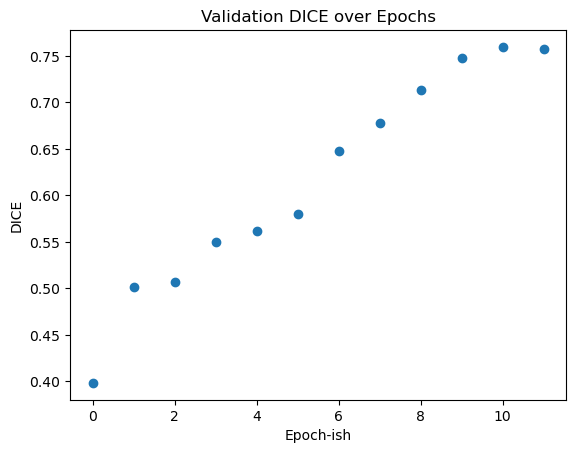

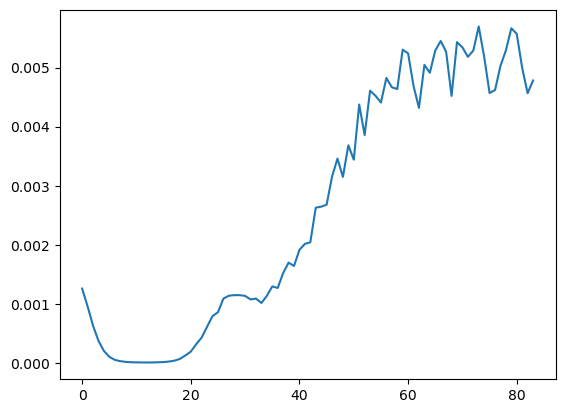

In [ ]:
x = np.array(range(len(dice_scores)))
plt.scatter(x, dice_scores)
plt.title("Validation DICE over Epochs")
plt.xlabel("Epoch-ish")
plt.ylabel("DICE")
plt.show()

plt.plot(usls)

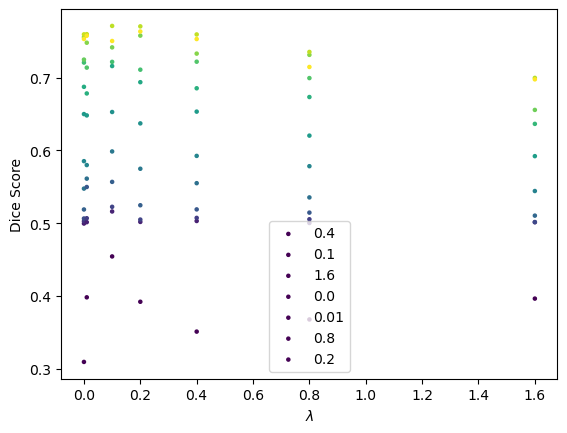

In [ ]:
logs = "training-logs/" + np.array(os.listdir("training-logs"))

cmap = plt.colormaps['viridis']

for log in logs:
    with open(log, "r") as file:
        text = "\n".join(file.readlines())
    
    lambda_match = re.search(r"LAMBDA\s*=\s*([0-9.]+)", text)
    lambda_val = float(lambda_match.group(1)) if lambda_match else None
    dice_vals = [float(x) for x in re.findall(r"DICE:\s*([0-9.]+)", text)]
    n = len(dice_vals)

    plt.scatter(np.ones(n) * lambda_val, dice_vals, label=f"{lambda_val}", c=cmap(np.linspace(0,1,n)), s=5)
    
plt.ylabel("Dice Score")
plt.xlabel("$\\lambda$")
plt.legend()

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


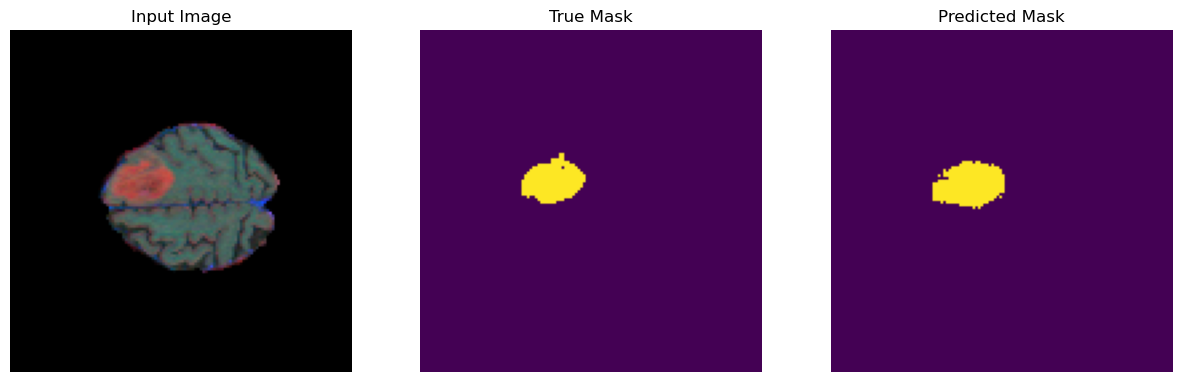

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


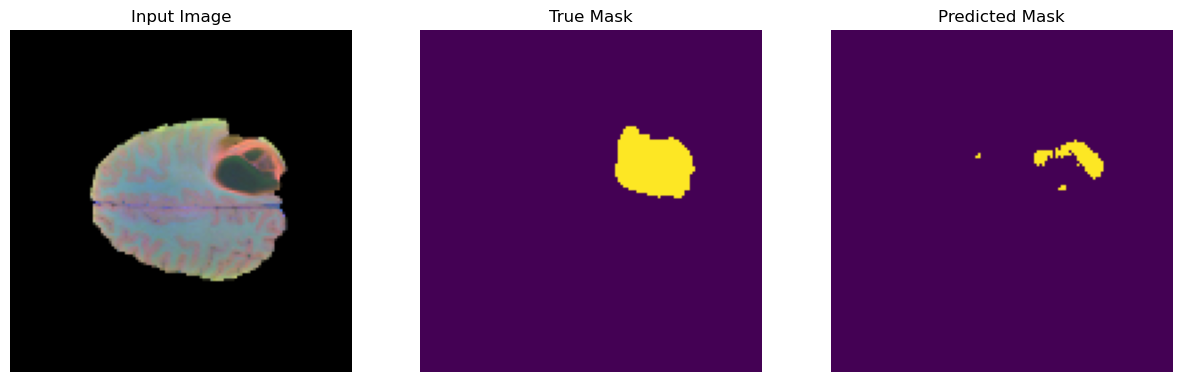

In [ ]:
show_predictions(val_batches, 2)

<img src="shrimple.gif">